# Predicting heart disease using machine learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

We're going to take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition
Given clinical parameters about a patient, can we predict whether or not they have heart disease?

## 2. Data

The original data is from the Cleavland data from the [UCI Machine Learning Repository.](https://archive.ics.uci.edu/ml/datasets/heart+Disease)
Another version of it is available on [Kaggle.](https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset) 

## 3. Evaluation
If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project.

## 4. Features
1. age - age in years
2. sex - (1 = male; 0 = female)
3. cp - chest pain type
    * 0: Typical angina: chest pain related decrease blood supply to the heart
    * 1: Atypical angina: chest pain not related to heart
    * 2: Non-anginal pain: typically esophageal spasms (non heart related)
    * 3: Asymptomatic: chest pain not showing signs of disease
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital) anything above 130-140 is typically cause for concern
5. chol - serum cholestoral in mg/dl
    * serum = LDL + HDL + .2 * triglycerides
    * above 200 is cause for concern
6. fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
    * '>126' mg/dL signals diabetes
7. restecg - resting electrocardiographic results
    * 0: Nothing to note
    * 1: ST-T Wave abnormality
        * can range from mild symptoms to severe problems
        * signals non-normal heart beat
    * 2: Possible or definite left ventricular hypertrophy
        * Enlarged heart's main pumping chamber
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina (1 = yes; 0 = no)
10. oldpeak - ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more
11. slope - the slope of the peak exercise ST segment
    * 0: Upsloping: better heart rate with excercise (uncommon)
    * 1: Flatsloping: minimal change (typical healthy heart)
    * 2: Downslopins: signs of unhealthy heart
12. ca - number of major vessels (0-3) colored by flourosopy
    * colored vessel means the doctor can see the blood passing through
    * the more blood movement the better (no clots)
13. thal - thalium stress result
    * 1,3: normal
    * 6: fixed defect: used to be defect but ok now
    * 7: reversable defect: no proper blood movement when excercising
14. target - have disease or not (1=yes, 0=no) (= the predicted attribute)

## Preparing the tools

In [1]:
#All imports

# Import EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Importing models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import RocCurveDisplay

## Loading data

In [2]:
df = pd.read_csv("data/heart-disease.csv")
df.shape, df.head()

((303, 14),
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
 0   63    1   3       145   233    1        0      150      0      2.3      0   
 1   37    1   2       130   250    0        1      187      0      3.5      0   
 2   41    0   1       130   204    0        0      172      0      1.4      2   
 3   56    1   1       120   236    0        1      178      0      0.8      2   
 4   57    0   0       120   354    0        1      163      1      0.6      2   
 
    ca  thal  target  
 0   0     1       1  
 1   0     2       1  
 2   0     2       1  
 3   0     2       1  
 4   0     2       1  )

## Data exploration (or exploratory data analysis-EDA)
The goal here is to find out more about the data we are working with.
* What question(s) are you trying to solve?
* What kind of data do we have and how do we treat different types?
* What's missing from the data and how do you deal with it?
* Where are the outliers and why should you care about them?
* How can you add, change or remove features to get more out of your data?

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

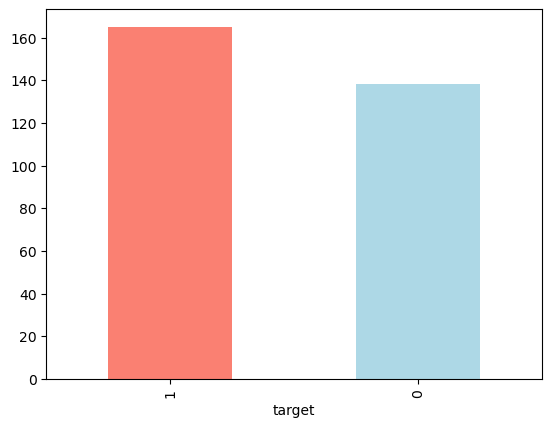

In [6]:
df["target"].value_counts().plot(kind="bar", color=["salmon","lightblue"]);

Dataset contains almost equal amout of patience with (165) and without heart disease (138).

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency corelated to sex

In [10]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [11]:
# Compare target with sex
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


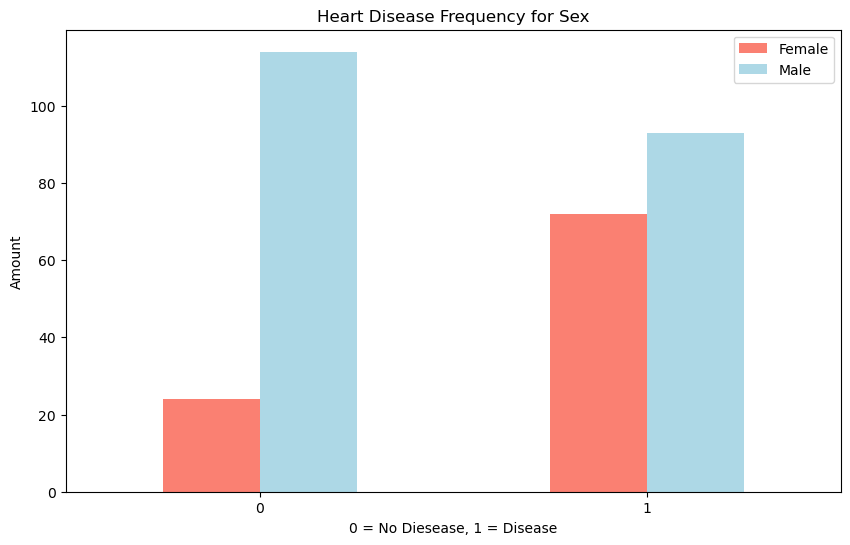

In [12]:
# Create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10, 6),
                                    color=["salmon", "lightblue"])

plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Diesease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"]);
plt.xticks(rotation=0);

The dataset contains considerably more male patients (207) than female patients (96).
Among male patients, the distribution is more balanced, though heart disease remains slightly less frequent than in females within this dataset.
    
This suggests that sex may contain predictive information and should be retained as a feature during model training.

### Age vs. Max Heart Rate for Heart Disease

Checking a hypothesis that age is strongly correlated with heart diseases.

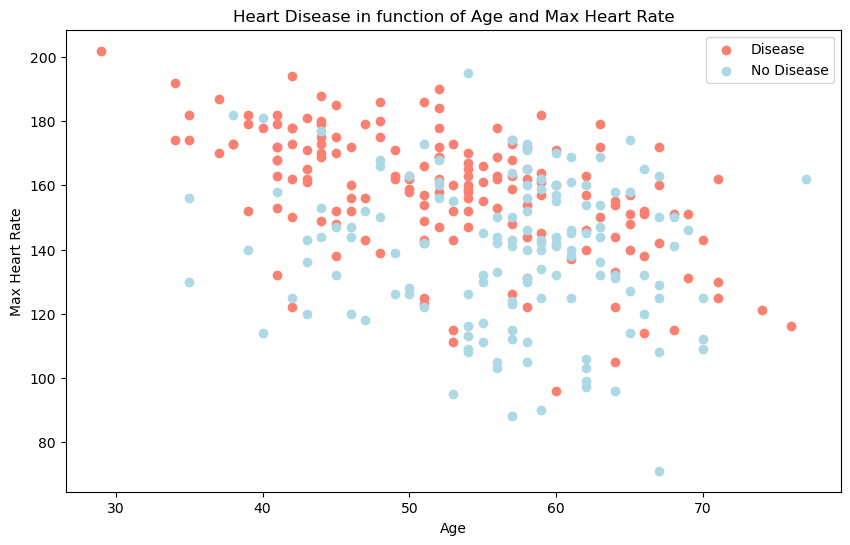

In [13]:
# Create a figure
plt.figure(figsize=(10, 6))

# Scatter with postivie examples
plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            c="salmon")

# Scatter with negative examples
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c="lightblue")

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

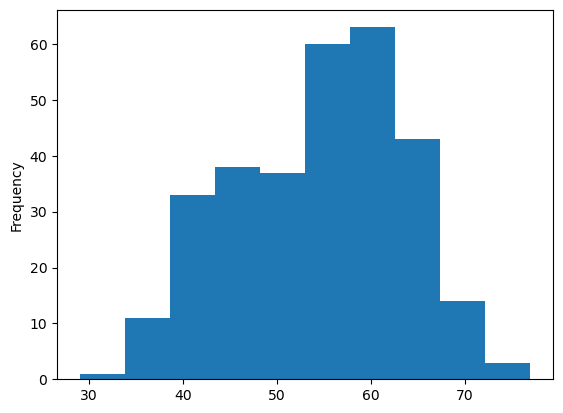

In [14]:
# Check the distribution of the age column with a histogram
df.age.plot.hist();

Most patients in the dataset are between 45 and 65 years old.

A negative relationship can be observed between age and maximum heart rate, with older patients generally achieving lower maximum heart rates.

Patients diagnosed with heart disease appear more concentrated in the lower heart-rate ranges, suggesting that both age and maximum heart rate may provide predictive value for classification.

### Heart Disease Frequency per Chest Pain Type

3. cp - chest pain type
- 0: Typical angina: chest pain related decrease blood supply to the heart
- 1: Atypical angina: chest pain not related to heart
- 2: Non-anginal pain: typically esophageal spasms (non heart related)
- 3: Asymptomatic: chest pain not showing signs of disease

In [15]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


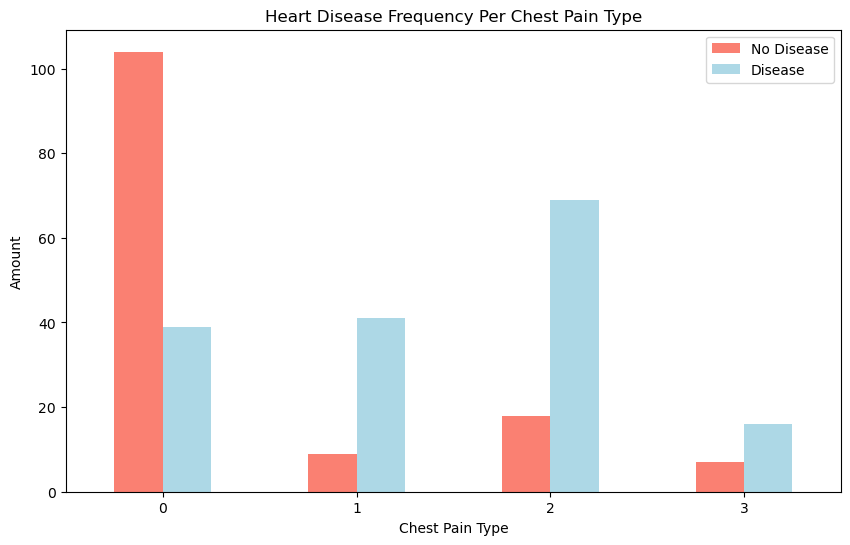

In [16]:
# Make the crosstab more visual
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10, 6),
                                   color=["salmon", "lightblue"])

# Add some communication
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0);

Chest pain type shows a strong relationship with the target variable.

Patients with chest pain type 0 are much more likely to belong to the non-disease group (104 vs 39).

In contrast, chest pain types 1, 2, and 3 are associated with a substantially higher frequency of heart disease cases, particularly type 2 (69 vs 18).

This suggests that chest pain type is likely to be one of the most informative features for predicting heart disease.

### Feature correlation analysis

To better understand which variables may contribute most to heart disease prediction, we'll perform a correlation analysis all features.

In [17]:
# Make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


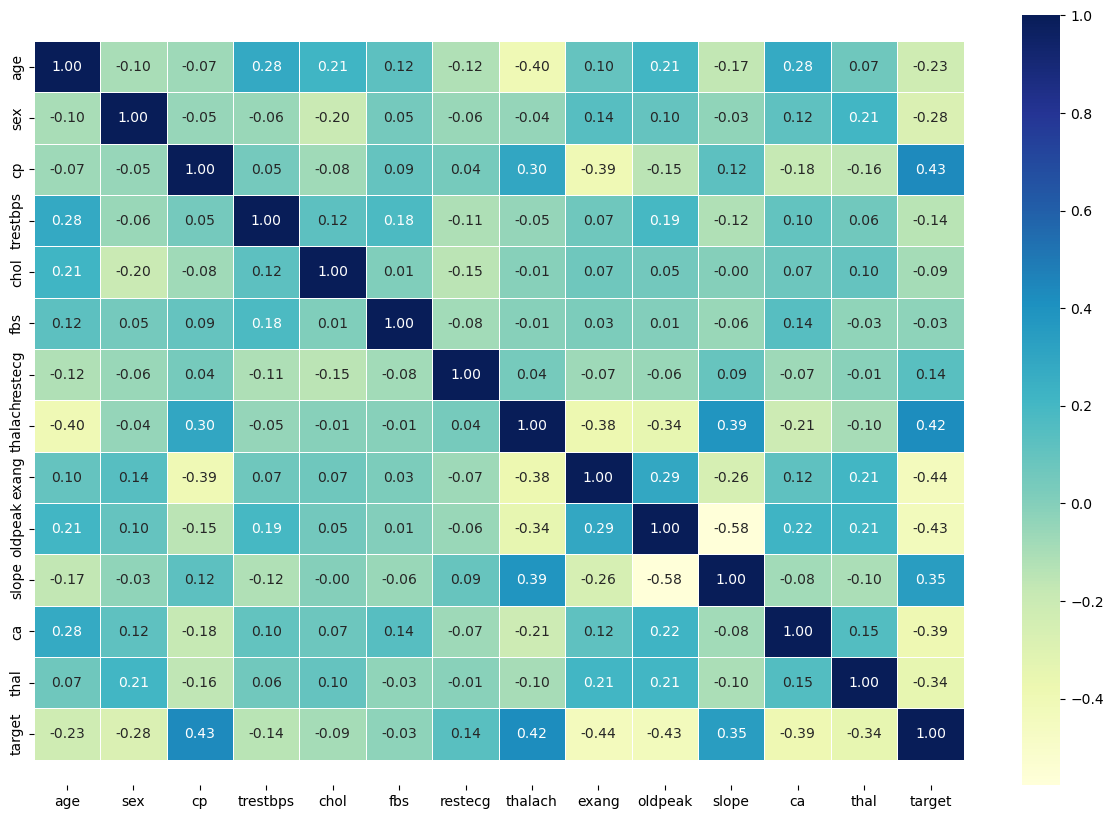

In [18]:
# Correlation matrix heatmap

corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(15, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    linewidths=0.5,
    fmt=".2f",
    cmap="YlGnBu",
    ax=ax
)

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

# Save figure
fig.savefig("images/correlation_heatmap.png",
            bbox_inches="tight",
            dpi=300)

plt.show()

#### Summary of the feature correlation analysis
The features most strongly associated with heart disease are:

- Chest Pain Type (`cp`) : +0.43
- Maximum Heart Rate Achieved (`thalach`) : +0.42
- ST Segment Slope (`slope`) : +0.35

The strongest negative relationships with heart disease were:

- Exercise Induced Angina (`exang`) : -0.44
- ST Depression (`oldpeak`) : -0.43
- Number of Major Vessels (`ca`) : -0.39

No single feature exhibits an extremely strong correlation with the target, suggesting that the model will likely benefit from combining information from multiple clinical variables.

## 5. Modelling

In [19]:
X = df.drop("target",axis = 1)

y = df["target"]

In [20]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [21]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [22]:
np.random.seed(8)

X_train,X_test, y_train, y_test = train_test_split(X, 
                                                   y,
                                                   test_size=0.2)

In [23]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
37,54,1,2,150,232,0,0,165,0,1.6,2,0,3
137,62,1,1,128,208,1,0,140,0,0.0,2,0,2
231,57,1,0,165,289,1,0,124,0,1.0,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3
48,53,0,2,128,216,0,0,115,0,0.0,2,0,0
191,58,1,0,128,216,0,0,131,1,2.2,1,3,3
136,60,0,2,120,178,1,1,96,0,0.0,2,0,2


We're going to try 3 different machine learning models:

- Logistic Regression
- K-Nearest Neighbours Classifier
- Random Forest Classifier

In [24]:
# Put models in a dictionary
RANDOM_STATE = 8
models = {"Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE)}

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data (no labels)
    X_test : testing data (no labels)
    y_train : training labels
    y_test : test labels
    """
    # Make a dictionary to keep model scores
    model_scores = {}
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [25]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)

model_scores

{'Logistic Regression': 0.8688524590163934,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8524590163934426}

### Baseline Results

The baseline evaluation showed that Logistic Regression and Random Forest achieved similar performance, significantly outperforming K-Nearest Neighbors.

| Model | Accuracy |
|---------|---------|
| Logistic Regression | 86.9% |
| Random Forest | 85.2% |
| KNN | 68.9% |

Given the strong performance of Logistic Regression and Random Forest, these models were selected for further hyperparameter tuning with GridSearchCV and RandomizedSearchCV

## Model comparison

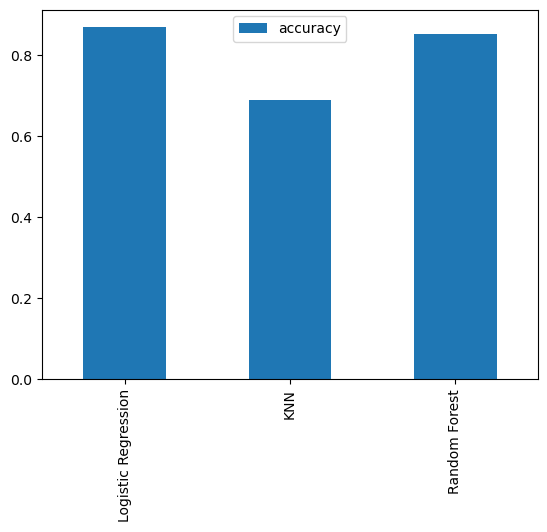

In [26]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();

### Next steps
- Hypeterparameter tuning
- Feature importance
- Confusion matrix
- Cross-validation
- Precision
- Recall
- F1 score
- Classification report
- ROC curve
- Area under the curve (AUC)

## Hyperparameter Tuning Strategy

Two tuning approaches were used:

1. `RandomizedSearchCV` to explore a broad range of hyperparameters efficiently.
2. `GridSearchCV` to perform a more focused search around promising parameter values.

This approach balances experimentation quality with computational efficiency.

### Hyperparameter tuning with RandomizedSearchCV

In [27]:
# Hyperparameter search space for Logistic Regression
#
# C controls regularization strength:
# - Small values -> stronger regularization
# - Large values -> weaker regularization
#
# A logarithmic scale is used because useful values often span
# several orders of magnitude.
#
# l1_ratio controls the type of regularization:
# - 0 behaves like L2 regularization
# - 1 behaves like L1 regularization
#
# This avoids using the deprecated 'penalty' parameter in newer
# versions of scikit-learn.
#
# The 'liblinear' solver was selected because it supports both
# L1 and L2 penalties and performs well on small datasets.

log_reg_grid = {
    "C": np.logspace(-4, 4, 30),
    "solver": ["liblinear"],
    "l1_ratio": [0, 1]
}

In [28]:
# Hyperparameter search space for Random Forest
#
# n_estimators:
# Number of trees in the forest.
# Values between 100 and 500 were selected because this dataset
# contains only 303 samples and larger forests are unlikely to
# provide significant additional benefit.
#
# max_depth:
# Controls how deep individual trees may grow.
# Shallower trees help reduce overfitting.
#
# min_samples_split:
# Minimum number of samples required to split a node.
# Larger values encourage simpler and more generalizable trees.
#
# min_samples_leaf:
# Minimum number of samples required in a leaf node.
# Helps prevent the model from learning noise.
#
# max_features:
# Number of features considered at each split.
# 'sqrt' and 'log2' are common choices that often improve
# Random Forest generalization performance.

rf_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [29]:
# Tune LogisticRegression
# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=2,
                                random_state= RANDOM_STATE)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END .............C=0.0001, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END .............C=0.0001, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END .............C=0.0001, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END .............C=0.0001, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END .............C=0.0001, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END .C=221.22162910704503, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END .C=221.22162910704503, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END .C=221.22162910704503, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END .C=221.22162910704503, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END .C=221.22162910704503, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END .C=17.433288221999874, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END .C=17.433288221999874, l1_ratio=1, sol

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'l1_ratio': [0, 1], 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed 

In [30]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'l1_ratio': 0, 'C': np.float64(1.3738237958832638)}

In [31]:
rs_log_reg.score(X_test, y_test)

0.8688524590163934

In [32]:
# Setup random hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(), 
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=2,
                           random_state= RANDOM_STATE)

# Fit random hyperparameter search model for RandomForestClassifier()
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estim

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ve

In [33]:
rs_rf.best_params_

{'n_estimators': 200,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 3}

In [34]:
# Evaluate the randomized search RandomForestClassifier model
rs_rf.score(X_test, y_test)

0.9016393442622951

#### Randomized Search Results

Hyperparameter tuning was performed for both Logistic Regression and Random Forest.

Logistic Regression achieved its best performance using moderate regularization (C ≈ 1.37) and retained the same test accuracy as the baseline model (86.9%).

Random Forest selected a more constrained configuration, including a maximum depth of 10 and a minimum leaf size of 4. While these settings may improve generalization during cross-validation, the resulting test accuracy (83.6%) was slightly lower than the baseline model.

These results suggest that Logistic Regression remains the strongest candidate for this dataset.

### Hyperparamter Tuning with GridSearchCV

In [35]:
# Focused grid search around promising C values found during earlier tuning.
# The goal is not to search the entire parameter space again, but to refine
# Logistic Regression regularization strength around values that performed well.

log_reg_grid_refined = {
    "C": [0.1, 0.15, 0.2, 0.204, 0.25, 0.3, 0.5, 1.0, 1.37],
    "solver": ["liblinear"],
    "l1_ratio": [0]
}

gs_log_reg = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=log_reg_grid_refined,
    cv=5,
    verbose=0
)

gs_log_reg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.15, ...], 'l1_ratio': [0], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [36]:
gs_log_reg.best_score_, gs_log_reg.best_params_

(np.float64(0.8097789115646259),
 {'C': 1.37, 'l1_ratio': 0, 'solver': 'liblinear'})

In [37]:
gs_log_reg.score(X_test,y_test)

0.8688524590163934

#### Grid Search Results

GridSearchCV selected `C=1.37`, `l1_ratio=0`, and `solver='liblinear'`.

The tuned model achieved 86.9% accuracy on the test set, matching the baseline Logistic Regression model.

This suggests that the default Logistic Regression configuration was already well-suited for this dataset, and additional tuning did not produce a meaningful improvement.

### Final Model Selection

Logistic Regression was selected as the final model because it achieved the highest overall performance while remaining simple and interpretable.

Although hyperparameter tuning did not improve test accuracy, the tuning process confirmed that Logistic Regression was a strong and stable choice for this dataset.

## Evaluting our tuned machine learning classifier, beyond accuracy
- ROC curve and AUC score
- Confusion matrix
- Classification report
  
Later we'll perform a cross-validation for more fair model validation.

In [38]:
# Make predictions with tuned model
y_preds = gs_log_reg.predict(X_test)

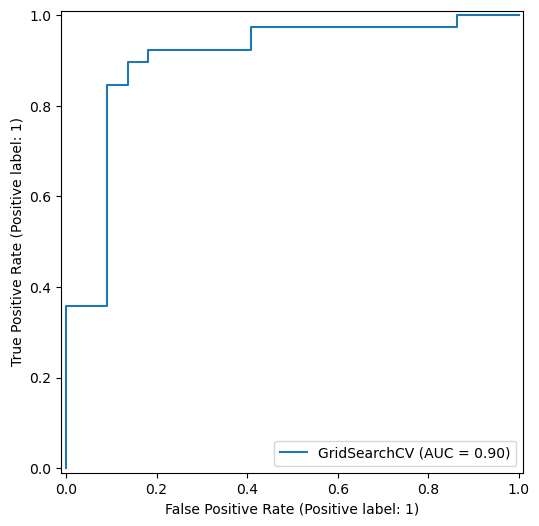

In [39]:
fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_estimator(
    gs_log_reg,
    X_test,
    y_test,
    ax=ax
)

fig.savefig("images/roc_curve.png",
            bbox_inches="tight",
            dpi=300)

plt.show()

#### ROC Curve and AUC

The final Logistic Regression model achieved an Area Under the ROC Curve (AUC) of 0.90.

An AUC score of 0.90 indicates high predictive capability, meaning the model can effectively distinguish between patients with and without heart disease across a range of classification thresholds.

#### Confusion Matrix

In [40]:
print(confusion_matrix(y_test, y_preds))

[[20  2]
 [ 6 33]]


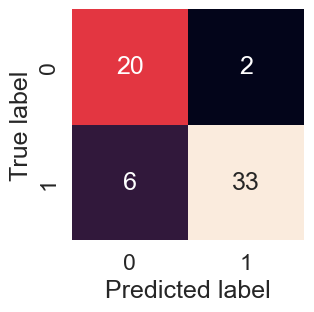

In [41]:
# Import Seaborn
import seaborn as sns
sns.set(font_scale=1.5) # Increase font size

def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("Predicted label") # predictions go on the x-axis
    plt.ylabel("True label") # true labels go on the y-axis

    fig.savefig("images/confusion_matrix.png",
            bbox_inches="tight",
            dpi=300)
    
plot_conf_mat(y_test, y_preds)

The model correctly classified:

- 20 patients without heart disease
- 33 patients with heart disease

Misclassifications included:

- 2 false positives
- 6 false negatives

The relatively low number of false positives and false negatives suggests the model generalizes well on the test dataset.

#### Classification report

In [42]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        22
           1       0.94      0.85      0.89        39

    accuracy                           0.87        61
   macro avg       0.86      0.88      0.86        61
weighted avg       0.88      0.87      0.87        61



The model achieved:

- Precision: 0.94 for heart disease detection
- Recall: 0.85 for heart disease detection
- F1-score: 0.89 for heart disease detection

High precision indicates that when the model predicts heart disease, it is usually correct.

High recall indicates that the majority of heart disease cases are successfully identified.

The balance between precision and recall is reflected in the strong F1-score of 0.89.

### Calculate evaluation metrics using cross-validation

To obtain a more robust estimate of model performance, 5-fold cross-validation was used.

Unlike a single train-test split, cross-validation evaluates the model across multiple data partitions, reducing the impact of random variation and providing a more reliable measure of generalization performance.

In [43]:
# Check best hyperparameters
gs_log_reg.best_params_

{'C': 1.37, 'l1_ratio': 0, 'solver': 'liblinear'}

In [44]:
# Create a new classifier with best parameters
clf = LogisticRegression(C=1.37, 
                         l1_ratio=0,
                         solver="liblinear",
                         max_iter=1000)

In [45]:
# Evaluate the final model using 5-fold cross-validation

scoring = ["accuracy", "precision", "recall", "f1"]

cv_results = cross_validate(
    clf,
    X,
    y,
    cv=5,
    scoring=scoring
)

# Calculate average scores across all folds

cv_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Score": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean()
    ]
})

cv_metrics

,Metric,Score
0,Accuracy,0.821530
1,Precision,0.817900
2,Recall,0.872727
3,F1,0.843174


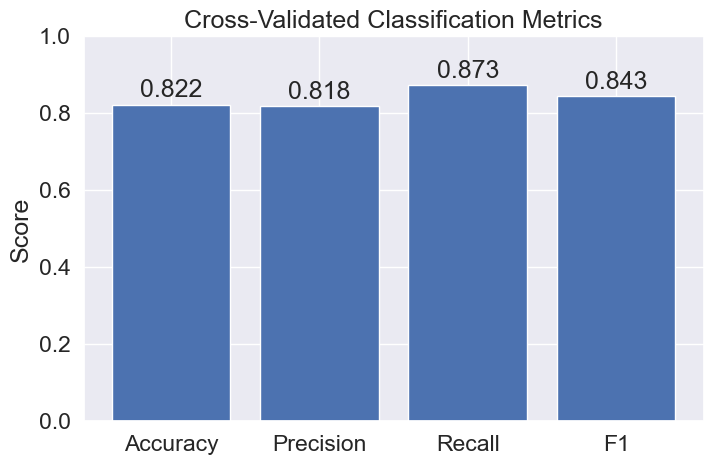

In [46]:
# Visualize cross-validated metrics

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    cv_metrics["Metric"],
    cv_metrics["Score"]
)

ax.set_title("Cross-Validated Classification Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

for index, value in enumerate(cv_metrics["Score"]):
    ax.text(
        index,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

#### Cross-Validation Results

The final Logistic Regression model achieved stable cross-validated performance:

| Metric | Score |
|---------|---------|
| Accuracy | 82.2% |
| Precision | 81.8% |
| Recall | 87.3% |
| F1 Score | 84.3% |

Recall is the strongest metric, meaning the model is relatively good at identifying positive heart disease cases.

This is useful for a medical classification problem, where missing a positive case is usually more costly than producing a false positive.

## Feature Importance and Model Interpretability

Feature importance is another as asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each machine learning model. One way to find feature importance is to search for "(MODEL NAME) feature importance".

Let's find the feature importance for our LogisticRegression model...

In [47]:
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.37
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [48]:
# Match coef's of features to columns
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'age': np.float64(0.012077938486893936),
 'sex': np.float64(-1.39677344761703),
 'cp': np.float64(0.7904304793579503),
 'trestbps': np.float64(-0.018192674003523396),
 'chol': np.float64(-0.005453871535215243),
 'fbs': np.float64(0.529488446324825),
 'restecg': np.float64(0.40486710463818243),
 'thalach': np.float64(0.036352656057284445),
 'exang': np.float64(-0.7311108658991626),
 'oldpeak': np.float64(-0.3777657513058066),
 'slope': np.float64(0.5586080839014329),
 'ca': np.float64(-0.9030507307824757),
 'thal': np.float64(-0.9743841032364678)}

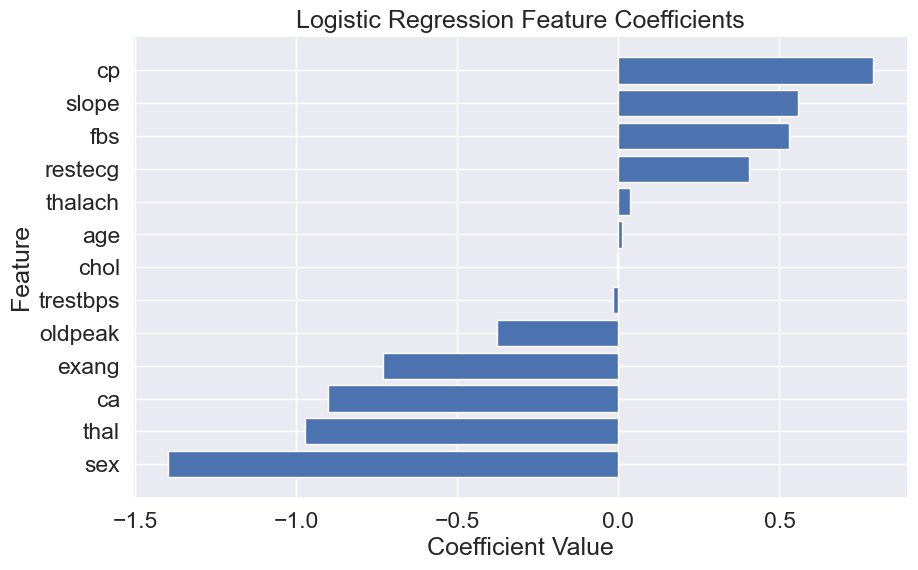

In [49]:
# Visualize feature importance

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": clf.coef_[0]
}).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    feature_df["Feature"],
    feature_df["Coefficient"]
)

ax.set_title("Logistic Regression Feature Coefficients")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

fig.savefig(
    "images/feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [50]:
pd.crosstab(df["sex"], df["target"])

target,0,1
sex,,
0,24,72
1,114,93


In [51]:
pd.crosstab(df["slope"], df["target"])

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


### Feature Importance Summary

The most influential positive features were:

- Chest pain type (`cp`)
- ST segment slope (`slope`)
- Resting ECG result (`restecg`)

The most influential negative features were:

- Sex (`sex`)
- Thalassemia result (`thal`)
- Number of major vessels (`ca`)
- Exercise-induced angina (`exang`)
- ST depression (`oldpeak`)

These results are broadly consistent with the EDA and correlation analysis, where several of the same clinical variables showed meaningful relationships with the target variable.

# 6. Future Improvements and Experimentation

This project achieved approximately **87% test accuracy** and demonstrated that Logistic Regression performs well on this dataset.

While the results are promising, several areas could be explored to further improve model performance and move the project closer to a production-ready machine learning workflow.

## 6.1 Collect More Data

The dataset contains approximately 300 observations, which limits the model's ability to generalize to unseen data.

A larger and more diverse dataset could:

- Reduce variance and overfitting
- Improve model robustness
- Provide more reliable performance estimates
- Better represent real-world patient populations

## 6.2 Evaluate Additional Models

This project evaluated Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest.

Future experiments could include:

- XGBoost
- LightGBM
- CatBoost

These algorithms often perform well on structured tabular datasets and may improve predictive performance.

## 6.3 Feature Engineering

Additional feature engineering could further improve model performance.

Potential areas for exploration include:

- Scaling numerical features
- Grouping ages into categories
- Feature selection techniques
- Investigating domain-specific medical features

# Conclusion

This project demonstrates an end-to-end supervised machine learning workflow, including exploratory data analysis, model selection, hyperparameter tuning, performance evaluation, cross-validation, and model interpretability.

Future work would focus on expanding the dataset, evaluating more advanced algorithms, and implementing deployment and MLOps best practices.

# 7. Model export (joblib)

In [52]:
import joblib

joblib.dump(
    gs_log_reg.best_estimator_,
    "models/heart_disease_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [53]:
loaded_model = joblib.load(
    "models/heart_disease_model.pkl"
)

loaded_model.score(X_test, y_test)

0.8688524590163934